In [1]:
import subprocess
import sys

# Install tensorflow (may take ~1 min)
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow', '-q'])

0

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
# Robustly load data: filter lines that start with a date (handles malformed rows)
import re
rows = []
with open('daily-minimum-temperatures-in-me.csv', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        # match lines like "YYYY-MM-DD",value or YYYY-MM-DD,value
        if re.match(r'^("?\d{4}-\d{2}-\d{2}"?),', line):
            parts = line.split(',')
            if len(parts) >= 2:
                date = parts[0].strip().strip('"')
                try:
                    val = float(parts[1])
                except:
                    continue
                rows.append((date, val))

df = pd.DataFrame(rows, columns=['Date', 'Temp'])
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [4]:
data = df['Temp'].values.reshape(-1,1)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

def create_sequences(data, steps=30):
    X, y = [], []
    for i in range(len(data)-steps):
        X.append(data[i:i+steps])
        y.append(data[i+steps])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, 30)

split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape, X_test.shape)


(2893, 30, 1) (724, 30, 1)


In [5]:
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=20, batch_size=32,
                    validation_data=(X_test,y_test))


Epoch 1/20


C:\Users\Loq\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


 1/91 ━━━━━━━━━━━━━━━━━━━━ 1:54 1s/step - loss: 0.2432

 8/91 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1918 

17/91 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1420

...

55/91 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0084

64/91 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0085

74/91 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0085

84/91 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0085

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0088 - val_loss: 0.0078


In [6]:
pred = model.predict(X_test)

pred_actual = scaler.inverse_transform(pred)
y_actual = scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_actual, pred_actual)
rmse = np.sqrt(mean_squared_error(y_actual, pred_actual))

print("MAE:", mae)
print("RMSE:", rmse)


 1/23 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step

21/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


MAE: 1.8331274857178579
RMSE: 2.3259834695527943


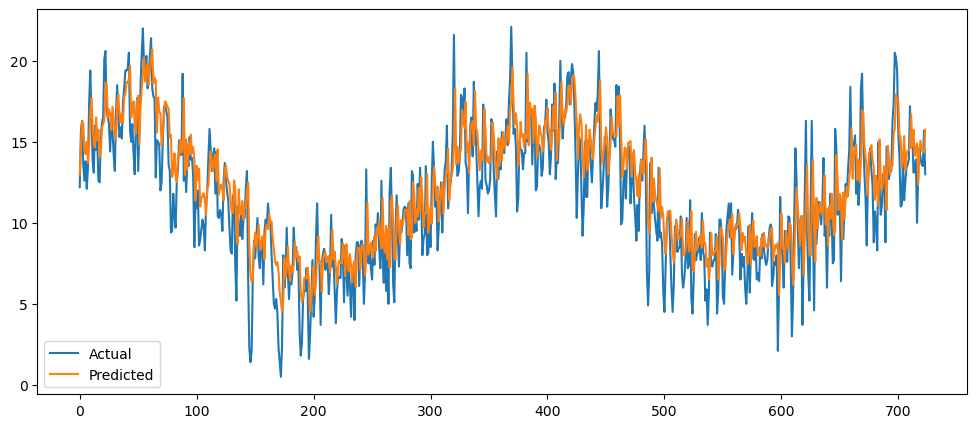

In [7]:
plt.figure(figsize=(12,5))
plt.plot(y_actual, label='Actual')
plt.plot(pred_actual, label='Predicted')
plt.legend()
plt.show()